# A quick usage example

In [ ]:
import os

#os.environ["MIEPOM_VECTORIZED_MIE"] = "1"  # Enable vectorized Mie calculations for better performance

import miepom.core as mp
import numpy as np

USEGPU = False

try:
    import mlx.core as mx
    mp.set_backend(mx)
    USEGPU = True
except ImportError:
    pass
    
try:
    import cupy as cp
    mp.set_backend(cp)
    USEGPU = True
except ImportError:
    pass

if USEGPU == False:
    print("GPU backend not available, using CPU backend. For better performance, install mlx or cupy.")




MIEPOM backend set to mlx.core


In [19]:

sensor_settings = {"shape": (512, 512) ,  
                   "pixel_size": 6.9e-6,  
                   "adcbit": 10,  
                   "pixel_aspect" : 2.0, 
                   "full_well_capacity": 2**15,  
                   "transmittance": 1.}

light_source_settings = {"wavelength": 532e-9,
                       "bandwidth": 29e-9,
                       #inntensity at the object plane
                       # because we are using 60x magnification, the intensity at the object plane is 60x60 times higher 
                       # than the intensity at the image plane, so we need to multiply the intensity by 60*60 
                       "intensity": 60*60}

microscope_settings = {"magnification": 60, 
                       "tube_lens_focal_length": 200e-3, 
                       # The refractive index of the immersion medium (e.g., water, oil, etc.)
                       # this is for future use, currently not used in the simulation
                       # currently, the simmulation assumes that the medium in which the particles are suspended has the same refractive index as the immersion medium of the objective lens
                       # regardless of what the user specifies here, the simulation will always use the refractive index of the immersion medium of the objective lens
                       # In the future, we will allow the user to specify the refractive index of the immersion medium to be different from the refractive index of the medium in which the particles are suspended, 
                       "immersion_medium_refractive_index": 1.33,
                       "objective_numerical_aperture": 0.9,
                       "condenser_numerical_aperture": 0.1}

sample_settings = {"diameter_mean": 0.3e-6,
                     "diameter_std": 0.01e-6,
                     "n_particle": 1.59,
                     "n_particle_std": 0.01,
                     "n_medium": 1.33,
                     "num_particles": 400,
                     "sample_thickness": 400e-6
                     }

simulator_settings = {"simulator_na": 1.0, 
                      "focal_plane": 200e-6, 
                      # Whether the particles are considered monodisperse or not - much faster to compute if monodisperse
                      "monodisperse_particles": False}

In [20]:
sensor = mp.create_sensor(**sensor_settings)
sensor.print_info()

Sensor settings
------------------------------------------------------------------------
Sensor shape:               (512, 512)
Sensor height:              2.50 mm
Sensor width:               5.00 mm
Sensor diagonal:            5.59 mm
Pixel size:                 6.90 um
Pixel aspect:               2.0
Exposure level:             0.50
Full well capacity:         32768 e-
ADC applied:                Yes
ADC bit depth:              10 bits
Shot noise applied:         Yes
Shot noise model:           Poisson



In [21]:
light_source = mp.create_light_source(**light_source_settings)
light_source.print_info()

Light source settings
----------------------
Intensity at object plane:  3600.00
Wavelength:                 532.00 nm
Bandwidth (FWHM):           29.00 nm
Frequency:                  5.64e+14 Hz
Wavenumber:                 1.18e+07 1/m
Wavenumber spread (sigma):  2.74e+05 1/m


In [22]:

microscope = mp.create_microscope(light_source=light_source, sensor=sensor, **microscope_settings)
microscope.print_info(full = False)

Microscope settings
----------------------
Magnification:                     60
Tube lens focal length:            2.00e-01 m
Immersion medium refractive index: 1.33
Objective numerical aperture:      0.9
Condenser numerical aperture:      0.1



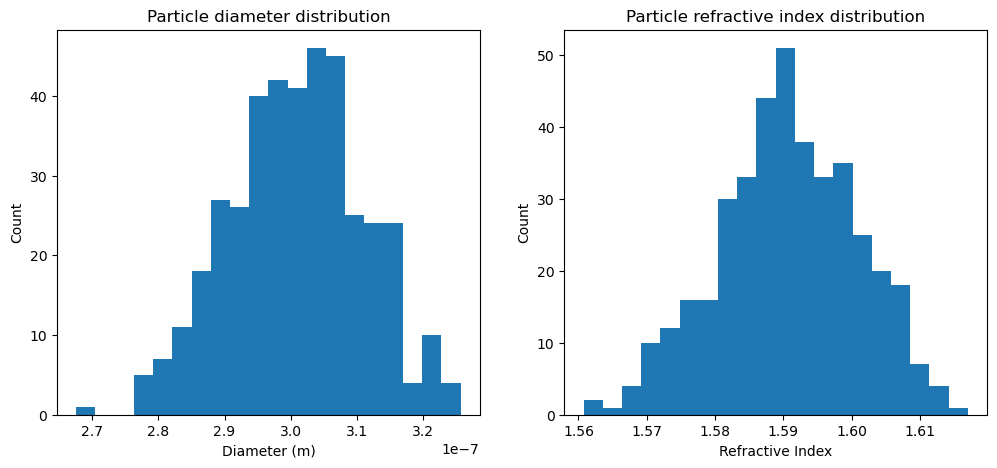

In [23]:
diameter_mean = sample_settings["diameter_mean"]
num_particles = sample_settings["num_particles"]
diameter_std = sample_settings["diameter_std"]
n_mean = sample_settings["n_particle"]
n_std = sample_settings["n_particle_std"]
n_medium = sample_settings["n_medium"]

object_plane = microscope.get_object_plane()

diameters = np.random.normal(loc = diameter_mean, scale = diameter_std, size = num_particles)
n = np.random.normal(loc = n_mean, scale = n_std, size = num_particles)

particles = mp.create_mie_particles(count = num_particles, diameter = diameters, n_particle = n, n_medium = n_medium)

particles.plot_distribution()

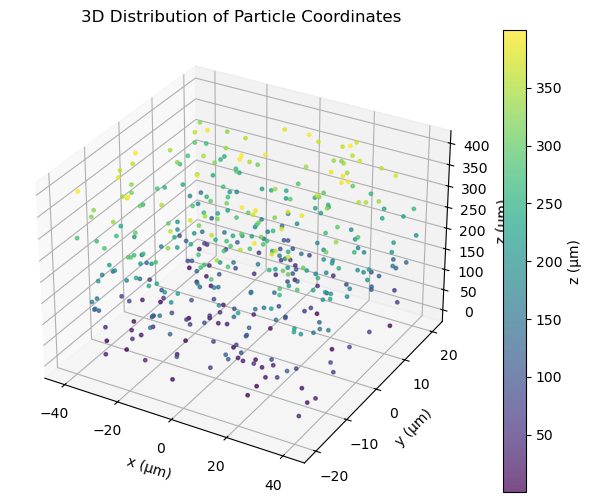

In [24]:
import matplotlib.pyplot as plt

sample_thickness = sample_settings["sample_thickness"]

coordinates = np.zeros((num_particles, 3))
coordinates[:, 0] = np.random.uniform(low = -object_plane.width/2, high = object_plane.width/2, size = (num_particles))
coordinates[:, 1] = np.random.uniform(low = -object_plane.height/2, high = object_plane.height/2, size = (num_particles))
coordinates[:, 2] = np.random.uniform(low = 0, high = sample_thickness, size = (num_particles))

particles.set_coordinates(coordinates)

particles.plot_coordinates()


|==================================================| 100.0 % Done in  0.7 s


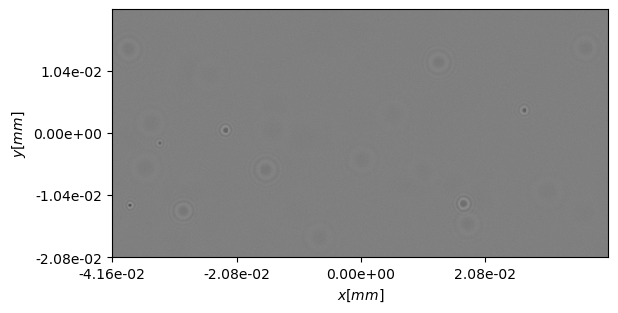

In [25]:
sim = mp.create_simulator(microscope, particles, **simulator_settings)
# Compute the lookup table for the simulator, this is a time-consuming step, but it only needs to be done once for a given set of particles and microscope settings
lut = sim.compute_lut()

object_plane.imshow(sim.compute_image(), cmap="gray", vmin=0, vmax=1)

In [26]:
from ipywidgets import interact, FloatSlider

def plot_image_with_controls(focal_plane, condenser_na, bandwidth):
    """Plot simulated image with controls for focal plane, condenser NA, and source bandwidth."""
    global lut

    # Update optical settings
    sim.set_focal_plane(focal_plane)
    microscope.condenser_numerical_aperture = condenser_na
    light_source.bandwidth = bandwidth 

    # Keep settings dicts in sync (optional)
    microscope_settings["condenser_numerical_aperture"] = condenser_na
    light_source_settings["bandwidth"] = bandwidth

    # Recompute LUT after optical changes
    im_temp = sim.compute_image()
    coords_um = sim.particles.coordinates * 1e6

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    object_plane.imshow(im_temp, ax=axes[0], cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(
        f"Focal: {focal_plane*1e6:.1f} µm | Cond. NA: {condenser_na:.2f} | BW: {bandwidth*1e9:.1f} nm"
    )
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("y")

    axes[1].scatter(coords_um[:, 0], coords_um[:, 2], alpha=0.5, s=4)
    axes[1].axhline(focal_plane * 1e6, color="r", linestyle="--", linewidth=2)
    axes[1].set_title("X-Z")
    axes[1].set_xlabel("x (µm)")
    axes[1].set_ylabel("z (µm)")
    axes[1].grid(True, alpha=0.3)

    axes[2].scatter(coords_um[:, 1], coords_um[:, 2], alpha=0.5, s=4, color="orange")
    axes[2].axhline(focal_plane * 1e6, color="r", linestyle="--", linewidth=2)
    axes[2].set_title("Y-Z")
    axes[2].set_xlabel("y (µm)")
    axes[2].set_ylabel("z (µm)")
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


focal_plane_slider = FloatSlider(
    value=simulator_settings["focal_plane"],
    min=0,
    max=sample_thickness,
    step=10e-6,
    description="Focal (m):",
    readout_format=".2e",
)

condenser_na_slider = FloatSlider(
    value=microscope_settings["condenser_numerical_aperture"],
    min=0.01,
    max=1.0,
    step=0.01,
    description="Cond. NA:",
    readout_format=".2f",
)

bandwidth_slider = FloatSlider(
    value=light_source_settings["bandwidth"],
    min=1e-9,
    max=100e-9,
    step=1e-9,
    description="BW (m):",
    readout_format=".1f",
)

interact(
    plot_image_with_controls,
    focal_plane=focal_plane_slider,
    condenser_na=condenser_na_slider,
    bandwidth=bandwidth_slider,
)

interactive(children=(FloatSlider(value=0.0002, description='Focal (m):', max=0.0004, readout_format='.2e', st…

<function __main__.plot_image_with_controls(focal_plane, condenser_na, bandwidth)>

In [18]:
timeit mp.eval(sim.compute_image())

12.8 ms ± 179 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
